In [15]:
## import libraries 
import os
import pathlib
import torch
from torch import nn

from PIL import Image
from torch.utils.data import Dataset , DataLoader
from torchvision import transforms, datasets
from typing import Tuple , Dict , List 

In [5]:
## check gpu 
!nvidia-smi

Fri May  8 14:54:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 582.53                 Driver Version: 582.53         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro P620                  WDDM  |   00000000:04:00.0  On |                  N/A |
| 34%   43C    P8            N/A  /  N/A  |     357MiB /   2048MiB |      7%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
##setup device 
device = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

In [6]:
## importing data from github 
import requests
import zipfile
from pathlib import Path

##setup path to a data floader
data_path = Path("data/")
image_path = data_path /"pizza_steak_sushi"

## if the image foalder doesent exist , download and prepare it 
if image_path.is_dir():
    print(f"{image_path} directory already exists...skipping download")
else:
    print(f"{image_path} does not exist , creating one...")
    image_path.mkdir(parents=True , exist_ok=True)

## download data
with open(data_path /"pizza_steak_sushi.zip","wb") as f: 
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Download pizza, steak and sushi data")
    f.write(request.content)

## unzip data
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip", "r") as zip_ref:
    print("unzip pizza steak and sushi data")
    zip_ref.extractall(image_path)

data\pizza_steak_sushi does not exist , creating one...
Download pizza, steak and sushi data
unzip pizza steak and sushi data


In [8]:
## data prepration 
def walk_thtough_dir(dir_path):
    """Walks through directory path returns its contant"""
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f" There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}")


walk_thtough_dir(image_path)

 There are 2 directories and 0 images in 'data\pizza_steak_sushi
 There are 3 directories and 0 images in 'data\pizza_steak_sushi\test
 There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza
 There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak
 There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi
 There are 3 directories and 0 images in 'data\pizza_steak_sushi\train
 There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza
 There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak
 There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi


In [9]:
## seting up training and test paths 
train_dir = image_path/"train" 
test_dir = image_path/"test"

train_dir , test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

data\pizza_steak_sushi\test\sushi\2394442.jpg
sushi
Random Image Path : data\pizza_steak_sushi\test\sushi\2394442.jpg
Image Class : sushi
Image Height : 408
Image Widht : 512


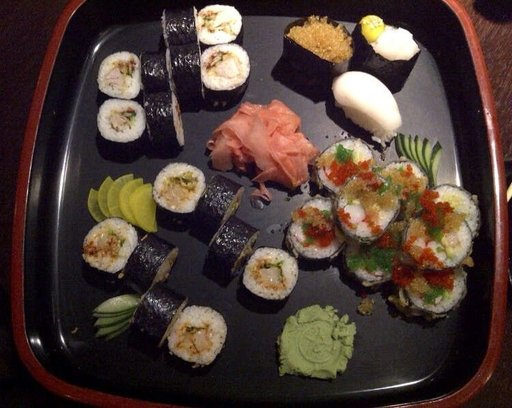

In [10]:
## visualize image
import random 
from PIL import Image

## set random seed
random.seed(42)

## get all image path 
image_path_list = list(image_path.glob("*/*/*.jpg"))  ## * refers to number of foalder jitny folader hyn otni dfa */

## pick a random image path 
random_image_path = random.choice(image_path_list)
print(random_image_path)

## Get image class from path name(image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
print(image_class)

## open Image
img = Image.open(random_image_path)

## print metadata
print(f"Random Image Path : {random_image_path}")
print(f"Image Class : {image_class}")
print(f"Image Height : {img.height}")
print(f"Image Widht : {img.width}")
img 
 


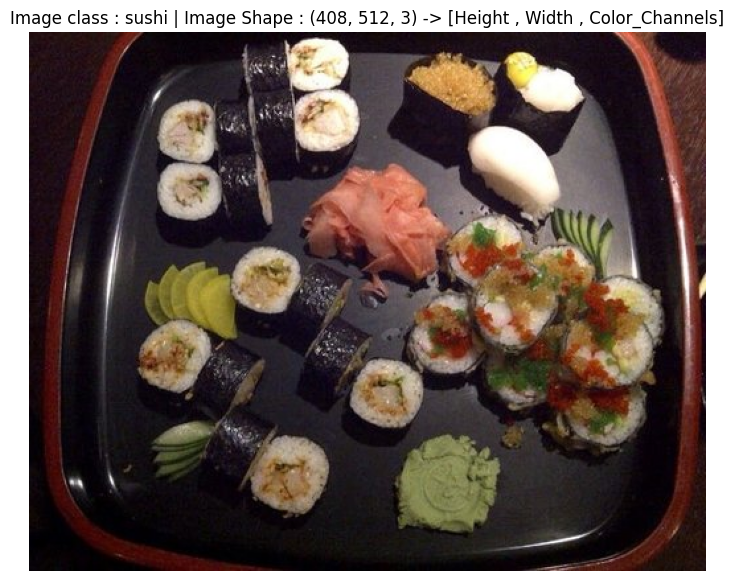

In [12]:
import numpy as np 
import matplotlib.pyplot as plt 

## turn image into array 
img_to_array = np.asarray(img)

## plot 
plt.figure(figsize=(10,7))
plt.imshow(img_to_array)
plt.title(f"Image class : {image_class} | Image Shape : {img_to_array.shape} -> [Height , Width , Color_Channels]")
plt.axis(False)
plt.show()

In [107]:
## write a transform for image
data_transform = transforms.Compose([
    ## resize your image to 64 x 64 (always)
    transforms.Resize(size = (64 , 64)),
    ## flip the image randomly on the horizontal 
    transforms.RandomHorizontalFlip(p=0.5),
    ## turn image into a torch.Tensor
    transforms.ToTensor()
])

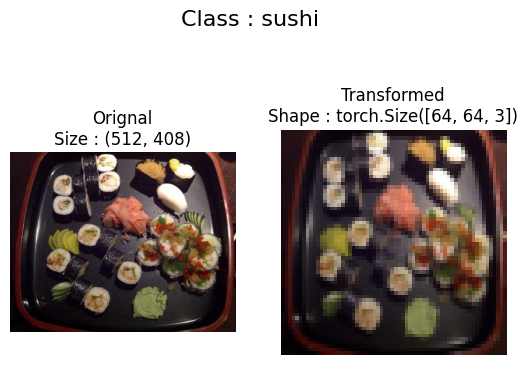

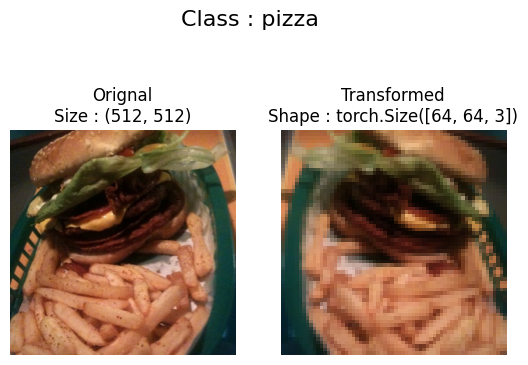

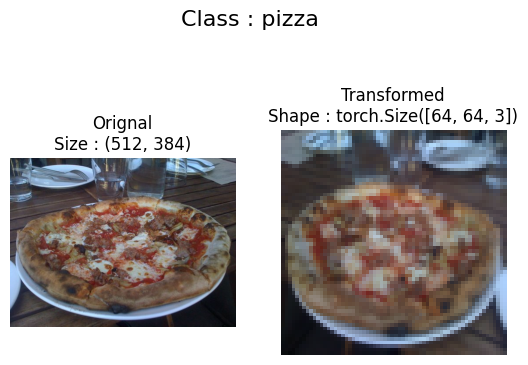

In [109]:
## write a code to plot transform images 
def plot_transformed_img(image_path: list , transform , n = 3 , seed = None):
    import random
    import matplotlib.pyplot as plt
    """
    Selects random images from a path of images and load/transform them plots the orignal va transformed version 
    """

    if seed:
        random.seed(seed)
    random_img_path = random.sample(image_path , k= n)
    for image_path in random_img_path:
        with Image.open(image_path) as f :
            fig,ax = plt.subplots(nrows= 1, ncols= 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Orignal\nSize : {f.size}")
            ax[0].axis(False)

            ## transform and plot target image 
            transformed_image = transform(f).permute(1,2,0)  ## we wil need to change shape for matplotlib it change (c,h,w) -> (h,w,c) 
            ax[1].imshow(transformed_image) 
            ax[1].set_title(f"Transformed\nShape : {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class : {image_path.parent.stem}" , fontsize = 16)

plot_transformed_img(image_path=image_path_list , transform=data_transform , n=3, seed= 42)


In [101]:
## loading image data using ImageFoalder
from torchvision import datasets
train_data  = datasets.ImageFolder(root= train_dir, ## root my data location ai gi , train_dir oper bnaya h train data k lye 
                                   transform=data_transform, ## transform my transform function ai ga jo data ko transform kry ga , data_transform uper function bnaya h  
                                   target_transform=None ## optinal h , label/ target ko transform karny k lye
)

test_data =  datasets.ImageFolder(root = test_dir , transform= data_transform)

train_data , test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [110]:
## get class names as a list 
class_names = train_data.classes
class_names 

['pizza', 'steak', 'sushi']

In [111]:
## get class name as dictionary 
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [112]:
## check the lendht of data 
len(train_data) , len(test_data)

(225, 75)

In [113]:
## Index on train_data datasets to  get a single image and label 
img, label  = train_data[0][0], train_data[0][1]
print(f"Image Tensor:\n{img}")
print(f"image shape : {img.shape}")
print(f"image data type:{img.dtype}")
print (f"image lable: {label}")
print(f"Label datatype : {type(label)}")

Image Tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

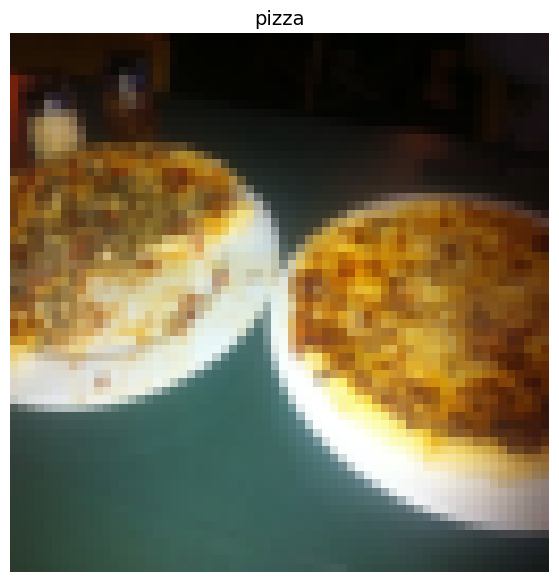

In [114]:
## rearrange the order dimenssion imp for deep learning always
img_permute = img.permute(1,2,0)

## plot images 
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize = 14)
plt.show()

In [115]:
  ## turn train and test data into data loader 
from torch.utils.data import DataLoader
Batch_Size = 1

train_dataloader = DataLoader(dataset= train_data , batch_size= Batch_Size , num_workers= 2, shuffle= True)  ## num_workers number of cpu  kitny working karwany hyn 
test_dataloader = DataLoader(dataset= test_data , batch_size= Batch_Size , num_workers= 2 , shuffle=False)

train_dataloader , test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x2c87e115ed0>,
 <torch.utils.data.dataloader.DataLoader at 0x2c8751977f0>)

In [116]:
len(train_dataloader) , len(test_dataloader)

(225, 75)

In [117]:
img, label = next(iter(train_dataloader))

print(f"Image shape: {img.shape}") ## formate will be [batch , color_channel  , height ,  weidth]
print(f"Label shape : {label.shape}")

Image shape: torch.Size([1, 3, 64, 64])
Label shape : torch.Size([1])


#### using custom dataset for converting image into tensors

In [31]:
## setup path for target directory 
target_directory = train_dir
print(f"target directory : {target_directory}")

## create a function 
def find_classes(directory : str) -> Tuple[List[str], Dict[str , int]]:
    """Finds the class foalder names in a target directory"""

    ## get the class name by scanning the target directory 
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    ## Raise an error if class nam couldn't found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}. please check file structure")
    
    ## create a dictionary of index labels
    class_to_idx = {class_name : i for i , class_name in enumerate(classes)}
    return classes , class_to_idx


target directory : data\pizza_steak_sushi\train


In [32]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [33]:
## write a custom dataset class
from torch.utils.data import Dataset

## create subclass 
class ImageFolderCustom(Dataset):

    ## initialize our custom dataset 
    def __init__(self, targ_dir :str , transform = None):
        ## create class attribute
        ## get all the image path 
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        ## set transform
        self.transform = transform
        ## create classes and class_to_idx attribute 
        self.classes , self.class_to_idx = find_classes(targ_dir)     

    ## create a function to load images 
    def load_image(self, index:int) -> Image.Image:   
        "Opens an image via a path and return image"
        image_path = self.paths[index]
        return Image.open(image_path)
    
    ## overwrite __len__()  
    def __len__(self) -> int:
        "Returns the total number of samples"
        return len(self.paths)
    
    ## overwrite __getitem__() 
    def __getitem__(self, index : int) -> Tuple[torch.Tensor,int]:
        "Return 1 sample of data, data and label(x,y)"
        img = self.load_image(index)
        class_name = self.paths[index].parent.name ## output formate : data_foalder / class_name / image.jpg
        class_idx = self.class_to_idx[class_name]
        
        ## transform if necessary 
        if self.transform:
            return self.transform(img), class_idx  
        else:
            return img , class_idx 


In [34]:
## create a transform 
train_transform = transforms.Compose([transforms.Resize(size = (64 , 64)),transforms.RandomHorizontalFlip(p=0.5),transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize(size = (64 , 64)),transforms.ToTensor()])

In [35]:
## Test our ImageFoaldercustom class
train_data_custom = ImageFolderCustom(targ_dir=train_dir , transform= train_transform)   ## train_dir uper bnai h 
test_data_custom = ImageFolderCustom(targ_dir=test_dir , transform= test_transform) 

train_data_custom , test_data_custom

(<__main__.ImageFolderCustom at 0x2c82f6335e0>,
 <__main__.ImageFolderCustom at 0x2c82f633400>)

In [36]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [37]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [38]:
## check the equality b/w orignal ImageFolader dataset and Image foalder custom dataset
print(train_data_custom.classes == train_data.classes)
print(test_data_custom.classes == test_data.classes)

True
True


In [39]:
## write a function to visualize random images from our custom data set 
def display_random_images(dataset : torch.utils.data.Dataset , classes : List[str] = None , n : int = 10 , display_shape : bool = True , seed : int = None):

    ## adjust display if n is too high 
    if n>10:
        n=10
        display_shape = False
        print(f"For display purposes n shouldn't br larger than 10 , setting to 10 and removing shape display")

    ## set random seed
    if seed: 
        random.seed(seed)

    ## get random sample indexes 
    random_sample_idx = random.sample(range(len(dataset)), k =n)

    ## setup plot
    plt.figure(figsize=(16,8))

    ## loop through random indexes and plot them with matplotlib
    for i ,targ_sample in enumerate(random_sample_idx):
        targ_image , targ_label = dataset[targ_sample][0] , dataset[targ_sample][1]

        ## adjust ctensor dimmension for ploating
        targ_image_adjust = targ_image.permute(1,2,0)  # [c,h,w] to [h,w,c]

        ## plot adjust samples
        plt.subplot(1,n,i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"Class :{classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"

        plt.title(title)
        plt.show()


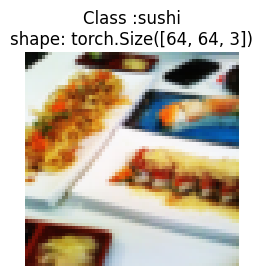

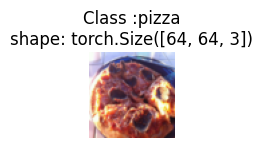

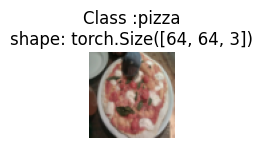

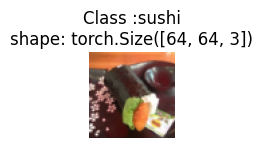

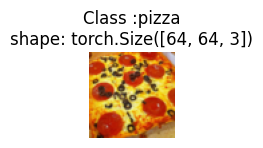

In [41]:
## display random images from ImageFoalder custom dataset
display_random_images(train_data_custom , n = 5, classes= class_names , seed= 42)

In [44]:
## turning custom data into dataloader
from torch.utils.data import DataLoader
Batch_Size = 1

train_dataloader_custom = DataLoader(dataset= train_data_custom , batch_size= Batch_Size , num_workers=0, shuffle= True)   
test_dataloader_custom = DataLoader(dataset= test_data_custom , batch_size= Batch_Size , num_workers= 0 , shuffle=False)

train_dataloader_custom , test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x2c82f53d1e0>,
 <torch.utils.data.dataloader.DataLoader at 0x2c82c76f580>)

In [45]:
img_custom, label_custom = next(iter(train_dataloader_custom))

print(f"Image shape: {img_custom.shape}") ## formate will be [batch , color_channel  , height ,  weidth]
print(f"Label shape : {label_custom.shape}")




Image shape: torch.Size([1, 3, 64, 64])
Label shape : torch.Size([1])


#### Data Augmentation 

In [46]:
## converting data into tensors 
train_transform = transforms.Compose({
    transforms.Resize(size=(244,244)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
})

test_transform = transforms.Compose({
    transforms.Resize(size=(244,244)),
    transforms.ToTensor()
})

In [47]:
## get all image path 
image_path_list = list(image_path.glob("*/*/*.jpg"))   
image_path_list[:10]

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg')]

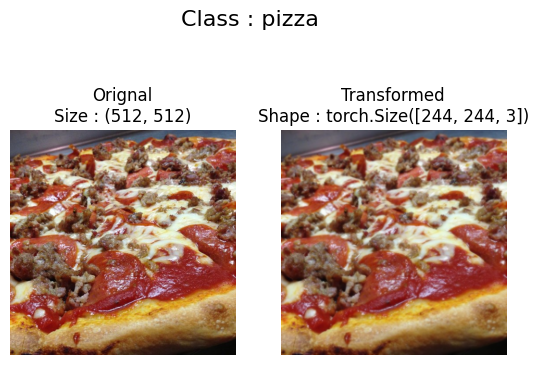

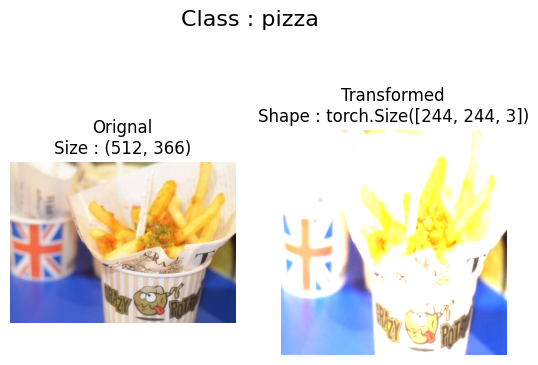

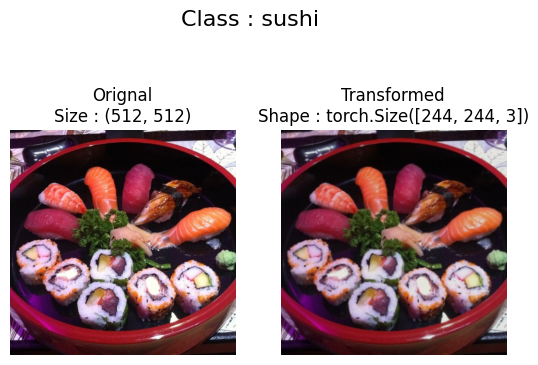

In [ ]:
## plot random transformed images 
plot_transformed_img(image_path=image_path_list , transform=train_transform, n=3, seed=None)  

## Building Model 


In [49]:
## creating transform and loading data 
simple_transform = transforms.Compose({
    transforms.Resize(size =(64,64)),
    transforms.ToTensor()
})

In [50]:
## load Data and transform 
train_data_simple = datasets.ImageFolder(root = train_dir , transform= simple_transform)  
test_data_simple = datasets.ImageFolder(root = test_dir , transform= simple_transform)

In [51]:
## turn data set in dataloader
import os 
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_simple = DataLoader(dataset=train_data_simple , batch_size=  BATCH_SIZE ,shuffle=True,  num_workers= NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset= test_data_simple , batch_size= BATCH_SIZE , shuffle= False , num_workers=NUM_WORKERS)

In [52]:
## build model class 
class TinyVGG(nn.Module):
    def __init__(self, input_shape : int , hiddden_unit : int , output_shape : int) -> None:
        super().__init__()   
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels= input_shape , out_channels= hiddden_unit , kernel_size= 3, stride =1 , padding= 0),
            nn.ReLU(),
            nn.Conv2d(in_channels= hiddden_unit , out_channels= hiddden_unit , kernel_size= 3, stride =1 , padding= 0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2 , stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels= hiddden_unit , out_channels= hiddden_unit , kernel_size= 3, stride =1 , padding= 0),
            nn.ReLU(),
            nn.Conv2d(in_channels= hiddden_unit , out_channels= hiddden_unit , kernel_size= 3, stride =1 , padding= 0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2 , stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x 


In [53]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3 , hiddden_unit=10 , output_shape= len(class_names)) ## input shape is color channel number in this

model_0 

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): LazyLinear(in_features=0, out_features=3, bias=True)
  )
)

In [54]:
## try forward pass on single image (to test the model)
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape , label_batch.shape 

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [55]:
model_0(image_batch)

tensor([[0.0097, 0.0057, 0.0329],
        [0.0098, 0.0118, 0.0300],
        [0.0101, 0.0143, 0.0314],
        [0.0109, 0.0082, 0.0320],
        [0.0080, 0.0114, 0.0308],
        [0.0119, 0.0068, 0.0308],
        [0.0114, 0.0081, 0.0347],
        [0.0134, 0.0067, 0.0327],
        [0.0099, 0.0100, 0.0314],
        [0.0108, 0.0074, 0.0338],
        [0.0090, 0.0103, 0.0318],
        [0.0104, 0.0046, 0.0314],
        [0.0116, 0.0068, 0.0339],
        [0.0106, 0.0113, 0.0266],
        [0.0142, 0.0065, 0.0309],
        [0.0114, 0.0074, 0.0327],
        [0.0115, 0.0072, 0.0349],
        [0.0120, 0.0036, 0.0322],
        [0.0077, 0.0086, 0.0326],
        [0.0106, 0.0104, 0.0339],
        [0.0095, 0.0076, 0.0340],
        [0.0113, 0.0080, 0.0327],
        [0.0127, 0.0065, 0.0313],
        [0.0120, 0.0083, 0.0327],
        [0.0129, 0.0084, 0.0303],
        [0.0080, 0.0110, 0.0336],
        [0.0088, 0.0100, 0.0312],
        [0.0095, 0.0113, 0.0280],
        [0.0109, 0.0098, 0.0332],
        [0.011

In [57]:
## use torch info to see summary of our model
from torchinfo import summary
summary(model_0 , input_size = [1,3,64,64], device=device)

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

In [58]:
## create a functionfor  train and test 
def train_step(model : torch.nn.Module, dataloader : torch.utils.data.DataLoader, loss_fn : torch.nn.Module , optimizer : torch.optim.Optimizer ,
                 device = device ):
    """perfoams a training with model trying to learn on data_loader"""

    ## put data in training mode
    model.train()

    train_loss , train_acc =0,0 



    ## training loop 
    # add a loop to loop through the training batches 
    for batch ,(X,y) in enumerate(dataloader):
        ## put data in target device 
        X,y = X.to(device),y.to(device)

        ## forward pass 
        y_pred = model(X)

        ## calculate loss and accuracy(per batch)
        loss = loss_fn(y_pred,y)
        train_loss += loss.item() ## accumilate train loss

        ## optimizer 
        optimizer.zero_grad()

        ## loss backword 
        loss.backward()

        ## optimizer step 
        optimizer.step()

        ## calculate accuracy matric
        y_pred_class = torch.argmax(torch.softmax(y_pred ,dim =1),dim=1)
        train_acc = (y_pred_class ==y).sum().item() / len(y_pred)

    ## Divide total train loss and accuracy  by lenght of train dataloader

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model : torch.nn.Module, dataloader : torch.utils.data.DataLoader, loss_fn : torch.nn.Module ,  device =device ):
    """Perfoam a testing loop on model going over data_loader"""
    
    
    ## put model in eval mod and turn on inference mode 
    model.eval()

    test_loss , test_acc = 0,0 

    with torch.inference_mode():
        for batch , (X, y) in enumerate(dataloader):

            ## send variable to target device
            X,y = X.to(device) , y.to(device)

            ## forward pass 
            test_pred_logits = model(X)

            ## calculate loss and accuracy (accumulatively)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim =1)
            test_acc += ((test_pred_labels ==y).sum().item() / len(test_pred_labels))

        ## calculate the test loss average per batch 
        test_loss = test_loss / len(dataloader)

        ## calculate the test accuracy average per batch 
        test_acc = test_acc / len(dataloader)

        ## print out whats happining 
        return test_loss, test_acc



In [59]:
## create train() function to combine train_step() and test_step()
from tqdm.auto import tqdm

## create a function 
def train(model : torch.nn.Module, train_data_loader : torch.utils.data.DataLoader, test_data_loader : torch.utils.data.DataLoader,
          optimizer : torch.optim.Optimizer,loss_fn : torch.nn.Module  = nn.CrossEntropyLoss(),epochs:int =5 , device : torch.device = None ):
    
    ## create empty result dictionary
    results = {"train_loss" : [],
               "train_acc"  : [],
               "test_loss" : [],
               "test_acc" : []}
    
    ## looping 
    for epoch in tqdm(range(epochs)):
        ## training 
        train_loss , train_acc = train_step(model=model ,dataloader=train_dataloader,loss_fn= loss_fn , optimizer=optimizer ,device= device )

        ## testing 
        test_loss, test_acc = test_step(model=model,dataloader=test_dataloader, loss_fn=loss_fn, device= device)

        ## print out what happen 
        print(f"Epoch : {epoch}  | Train loss : {train_loss:.4f}  |  Train accuracy : {train_acc:.4f} %  | Test loss : {test_loss: .4f} |  Test accuracy : {test_acc:.4f} %")

        ## update result dictionary 
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    ## return the filled result at the end of the epochs
    return results

c:\Users\Home Lab\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [60]:
## train and evaluate model 
torch.manual_seed(42)

## create device 
device = device

## set epoch 
Num_epochs = 5

## create model instance 
model_0 = TinyVGG(input_shape=3, hiddden_unit=10 , output_shape=len(train_data.classes)).to(device)

## setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr = 0.001)

## start time 
from timeit import default_timer as timer
start_timer = timer()

## train model 
model_0_resuts = train(model=model_0 , train_data_loader= train_dataloader_simple , test_data_loader= test_dataloader_simple, optimizer=optimizer,
                       loss_fn=loss_fn, epochs=Num_epochs , device= device)

## end timer 
end_time=timer()

print(f"Total traning time: {end_time-start_timer : .3f} seconds ")

 20%|██        | 1/5 [00:21<01:27, 21.97s/it]

Epoch : 0  | Train loss : 1.1034  |  Train accuracy : 0.0044 %  | Test loss :  1.0824 |  Test accuracy : 0.4133 %


 40%|████      | 2/5 [00:43<01:05, 21.90s/it]

Epoch : 1  | Train loss : 1.1051  |  Train accuracy : 0.0000 %  | Test loss :  1.0840 |  Test accuracy : 0.4933 %


 60%|██████    | 3/5 [01:05<00:43, 21.81s/it]

Epoch : 2  | Train loss : 0.9697  |  Train accuracy : 0.0044 %  | Test loss :  1.0183 |  Test accuracy : 0.4667 %


 80%|████████  | 4/5 [01:27<00:21, 21.76s/it]

Epoch : 3  | Train loss : 0.9443  |  Train accuracy : 0.0000 %  | Test loss :  0.9813 |  Test accuracy : 0.4400 %


100%|██████████| 5/5 [01:49<00:00, 21.81s/it]

Epoch : 4  | Train loss : 0.8710  |  Train accuracy : 0.0000 %  | Test loss :  1.0414 |  Test accuracy : 0.4000 %
Total traning time:  109.034 seconds 


In [61]:
model_0_resuts


{'train_loss': [1.1034452244970534,
  1.1051072755021354,
  0.9696915284047524,
  0.9443468198387159,
  0.870974568322094],
 'train_acc': [0.0044444444444444444, 0.0, 0.0044444444444444444, 0.0, 0.0],
 'test_loss': [1.0824008083343506,
  1.0839785166581473,
  1.0183004646499951,
  0.9812810826301575,
  1.0414376457532246],
 'test_acc': [0.41333333333333333,
  0.49333333333333335,
  0.4666666666666667,
  0.44,
  0.4]}

#### hyperparameter tuning

In [67]:
import optuna
import torch.optim as optim

In [64]:
## create accuracy function 
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

In [73]:
# Optuna objective function
def objective(trial):

    # Hyperparameters to tune
    hidden_unit = trial.suggest_int("hidden_unit", 8, 128, step=8)

    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["SGD", "Adam"]
    )

    epochs = trial.suggest_int("epochs", 5, 30, step=5)

    # Model → GPU
    model = TinyVGG(
        input_shape=3,
        hiddden_unit=hidden_unit,
        output_shape=len(class_names)
    ).to(device)

    # Loss function
    loss_fn = nn.CrossEntropyLoss()

    # Optimizer
    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    # Training loop
    for epoch in range(epochs):

        model.train()

        train_loss = 0

        for X, y in train_dataloader:

            # Move data to GPU
            X = X.to(device)
            y = y.to(device)

            # Forward pass
            y_logits = model(X)

            # Loss
            loss = loss_fn(y_logits, y)

            # Zero grad
            optimizer.zero_grad()

            # Backward
            loss.backward()

            # Optimizer step
            optimizer.step()

            train_loss += loss.item()

    # Validation
    model.eval()

    correct = 0
    total = 0

    with torch.inference_mode():

        for X, y in test_dataloader:

            # Move data to GPU
            X = X.to(device)
            y = y.to(device)

            test_logits = model(X)

            test_pred = torch.softmax(
                test_logits,
                dim=1
            ).argmax(dim=1)

            correct += (test_pred == y).sum().item()
            total += len(y)

    test_acc = correct / total

    # Optuna maximizes accuracy
    return test_acc

In [74]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

[I 2026-05-08 16:14:37,999] A new study created in memory with name: no-name-be60047a-bc04-49fb-a88f-96a36879b313
[I 2026-05-08 16:18:33,369] Trial 0 finished with value: 0.3333333333333333 and parameters: {'hidden_unit': 48, 'lr': 0.033270994341725035, 'optimizer': 'Adam', 'epochs': 20}. Best is trial 0 with value: 0.3333333333333333.
[I 2026-05-08 16:22:32,338] Trial 1 finished with value: 0.4666666666666667 and parameters: {'hidden_unit': 80, 'lr': 0.0013961491150743758, 'optimizer': 'SGD', 'epochs': 20}. Best is trial 1 with value: 0.4666666666666667.
[I 2026-05-08 16:26:33,646] Trial 2 finished with value: 0.56 and parameters: {'hidden_unit': 104, 'lr': 0.0030534530705843303, 'optimizer': 'SGD', 'epochs': 20}. Best is trial 2 with value: 0.56.
[I 2026-05-08 16:28:40,836] Trial 3 finished with value: 0.3333333333333333 and parameters: {'hidden_unit': 104, 'lr': 0.0038817245898824133, 'optimizer': 'Adam', 'epochs': 10}. Best is trial 2 with value: 0.56.
[I 2026-05-08 16:34:29,866] T

In [75]:
## best hyper perameters 
print("Best Trial:")
print(f"Accuracy: {study.best_value:.2f}%")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")


Best Trial:
Accuracy: 0.59%
Best Hyperparameters:
hidden_unit: 96
lr: 0.005641481790018685
optimizer: SGD
epochs: 25


In [76]:
##Train final model using best params
#  Best hyperparameters from Optuna
HIDDEN_UNIT = 96
LR = 0.005641481790018685
EPOCHS = 25

#  Final Model
final_model = TinyVGG(
    input_shape=3,
    hiddden_unit=HIDDEN_UNIT,
    output_shape=len(class_names)
).to(device)

#  Loss Function
loss_fn = nn.CrossEntropyLoss()

#  Optimizer → SGD from Optuna results
optimizer = optim.SGD(
    final_model.parameters(),
    lr=LR
)

#  Training Loop
for epoch in range(EPOCHS):

    final_model.train()

    train_loss = 0
    correct = 0
    total = 0

    for X, y in train_dataloader:

        #  Move data to GPU
        X = X.to(device)
        y = y.to(device)

        # Forward pass
        y_logits = final_model(X)

        # Loss
        loss = loss_fn(y_logits, y)

        # Zero gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        train_loss += loss.item()

        # Accuracy
        preds = torch.softmax(
            y_logits,
            dim=1
        ).argmax(dim=1)

        correct += (preds == y).sum().item()
        total += len(y)

    train_acc = correct / total

    #  Print progress
    print(
        f"Epoch: {epoch+1}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f}"
    )

Epoch: 1/25 | Loss: 247.4821 | Train Acc: 0.3156
Epoch: 2/25 | Loss: 238.4869 | Train Acc: 0.4267
Epoch: 3/25 | Loss: 222.4956 | Train Acc: 0.5067
Epoch: 4/25 | Loss: 211.7581 | Train Acc: 0.5600
Epoch: 5/25 | Loss: 200.9911 | Train Acc: 0.5956
Epoch: 6/25 | Loss: 203.0760 | Train Acc: 0.6089
Epoch: 7/25 | Loss: 189.6782 | Train Acc: 0.6311
Epoch: 8/25 | Loss: 193.6001 | Train Acc: 0.6178
Epoch: 9/25 | Loss: 180.1037 | Train Acc: 0.6667
Epoch: 10/25 | Loss: 172.2933 | Train Acc: 0.7067
Epoch: 11/25 | Loss: 173.4121 | Train Acc: 0.6578
Epoch: 12/25 | Loss: 154.4691 | Train Acc: 0.7156
Epoch: 13/25 | Loss: 151.2775 | Train Acc: 0.7200
Epoch: 14/25 | Loss: 145.6289 | Train Acc: 0.7333
Epoch: 15/25 | Loss: 136.0182 | Train Acc: 0.7289
Epoch: 16/25 | Loss: 122.1053 | Train Acc: 0.7511
Epoch: 17/25 | Loss: 100.5170 | Train Acc: 0.8267
Epoch: 18/25 | Loss: 114.7500 | Train Acc: 0.8178
Epoch: 19/25 | Loss: 96.9841 | Train Acc: 0.8489
Epoch: 20/25 | Loss: 71.0881 | Train Acc: 0.8800
Epoch: 21/2

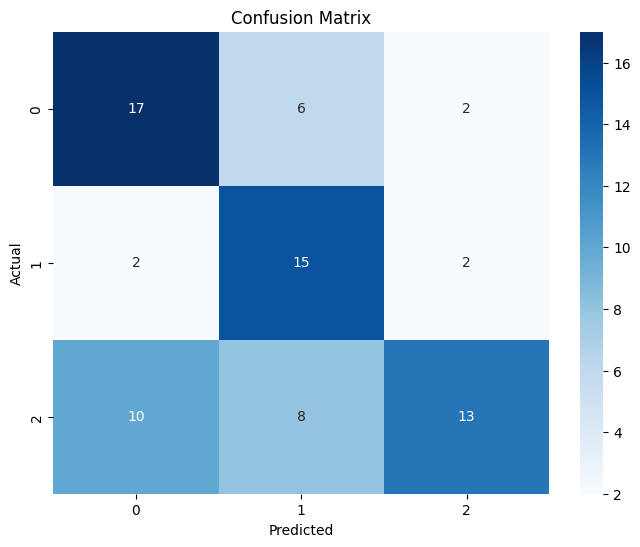

In [77]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

final_model.eval()
all_preds = []
all_labels = []

with torch.inference_mode():

    for X, y in test_dataloader:

        # Move data to GPU
        X = X.to(device)
        y = y.to(device)

        # Forward pass
        logits = final_model(X)

        # Predictions
        preds = torch.softmax(
            logits,
            dim=1
        ).argmax(dim=1)

        # Store predictions and labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### prediction on custom data 

In [82]:
## Download custom images
import requests

## setup custom images path
custom_image_path = data_path/"custom pic.png"

## download if it doesnt already exist
if not custom_image_path.is_file():
    with open(custom_image_path ,"wb") as f:
        request = requests.get("https://img.freepik.com/free-photo/front-view-delicious-cheese-pizza-consists-olives-pepper-tomatoes-dark-surface_179666-34391.jpg?t=st=1766614915~exp=1766618515~hmac=72a4fdd65aa80dec22c9963cb9c94abb10c8a4682266595663a1f2ba30fb32be&w=740")
        print(f"Downloading {custom_image_path}..............")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exist , skipping downloading ....")

data\custom pic.png already exist , skipping downloading ....


In [83]:
## loading custom image using pytorch 
import torchvision

## read custom image
custom_image_load = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255.  
print(f" Custom image tensor :\n {custom_image_load}")
print(f"custom image shape : {custom_image_load.shape}")
print(f"custom image dtypr : {custom_image_load.dtype}")


 Custom image tensor :
 tensor([[[0.2784, 0.2784, 0.2745,  ..., 0.2745, 0.2745, 0.2745],
         [0.2784, 0.2706, 0.2667,  ..., 0.2745, 0.2745, 0.2745],
         [0.2824, 0.2745, 0.2667,  ..., 0.2745, 0.2745, 0.2784],
         ...,
         [0.2784, 0.2941, 0.2980,  ..., 0.2902, 0.2745, 0.2627],
         [0.2980, 0.3020, 0.2980,  ..., 0.2902, 0.2745, 0.2588],
         [0.3020, 0.2980, 0.2941,  ..., 0.2667, 0.2588, 0.2588]],

        [[0.2706, 0.2706, 0.2667,  ..., 0.2706, 0.2706, 0.2706],
         [0.2706, 0.2627, 0.2588,  ..., 0.2706, 0.2706, 0.2706],
         [0.2745, 0.2667, 0.2588,  ..., 0.2706, 0.2706, 0.2745],
         ...,
         [0.2745, 0.2902, 0.2941,  ..., 0.3020, 0.2863, 0.2745],
         [0.2941, 0.2980, 0.2941,  ..., 0.2980, 0.2863, 0.2706],
         [0.2980, 0.2941, 0.2902,  ..., 0.2784, 0.2667, 0.2667]],

        [[0.2824, 0.2824, 0.2784,  ..., 0.2941, 0.2941, 0.2941],
         [0.2824, 0.2745, 0.2706,  ..., 0.2941, 0.2941, 0.2941],
         [0.2863, 0.2784, 0.2706, 

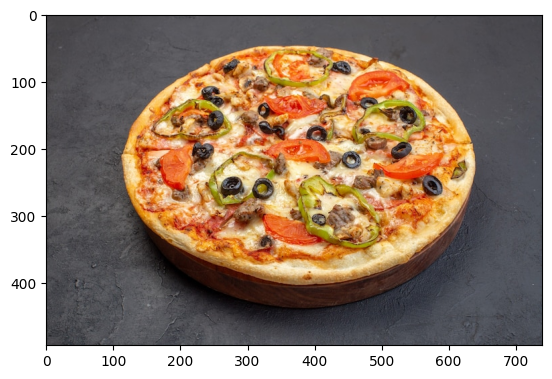

In [84]:
plt.imshow(custom_image_load.permute(1,2,0))
plt.show()

In [85]:
## create a transform pipeline to resize image 
from torchvision import transforms
custom_image_transform = transforms.Compose([
    transforms.Resize(size = (64,64))
])

custom_image_transformed = custom_image_transform(custom_image_load)

print(f"orignalshape : {custom_image_load.shape}")
print(f"transformed shape : {custom_image_transformed.shape}")

orignalshape : torch.Size([3, 493, 740])
transformed shape : torch.Size([3, 64, 64])


In [86]:
## try to do prediction
final_model.eval()

## this will answer in logits
with torch.inference_mode():
    custom_image_predict = final_model(custom_image_transformed.unsqueeze(0).to(device))  

## convert logits in pred_probs
custom_image_predict_prob = torch.softmax(custom_image_predict, dim=1)

## convert pred_prob into prediction label 
custom_image_predict_label = torch.argmax(custom_image_predict_prob, dim =1)

## print the predicted class name 
class_names[custom_image_predict_label]


'pizza'

In [87]:
custom_image_predict_label

tensor([0], device='cuda:0')

In [88]:
class_names

['pizza', 'steak', 'sushi']

In [89]:
def pred_and_plot_image(model: torch.nn.Module , image_path : str , class_names : List[str]=None, transform = None , device = device):
    """Makes a predicton on a target image with a trained model and plots the image and prediction."""

    ## load image
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32) / 255.

    ## Transform data if neccesary 
    if transform : 
        target_image = transform(target_image)

    ## makesure model is on target device
    model.to(device)

    ## make prediction 
    model.eval()
    with torch.inference_mode():
        target_image  = target_image.unsqueeze(0)
        target_image_pred =  model(target_image.to(device))
    
    ## convert logits into pred_prob then into pred_label
    target_image_pred_prob = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_prob, dim =1)  

    ## plot image with class name
    plt.imshow(target_image.squeeze().permute(1,2,0))
    if class_names:
        title = f"pred : {class_names[target_image_pred_label.cpu()]} | prob : {target_image_pred_prob.max().cpu():.3f}"
    else:
        prtitle = f"pred : {target_image_pred_label.cpu()} | prob : {target_image_pred_prob.max().cpu():.3f}"

    plt.title(title)
    plt.axis("off")
    plt.show()

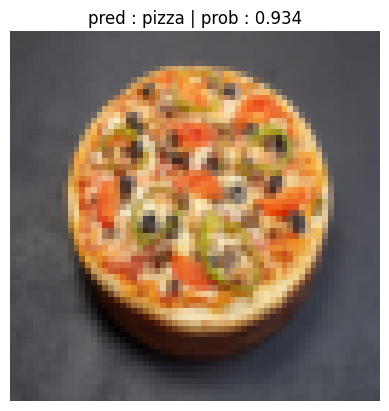

In [ ]:
## Making prediction on Final model
pred_and_plot_image(model= final_model , image_path=custom_image_path , class_names=class_names, transform=custom_image_transform, device= device)